#**Task 1: Term Deposit Subscription Prediction (Bank Marketing)**

In [1]:
!pip install shap -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import requests
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    roc_auc_score,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import shap

In [3]:
# Download UCI Bank Marketing Dataset
url = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"
zip_path = "bank_marketing.zip"

response = requests.get(url)
with open(zip_path, "wb") as file:
    file.write(response.content)

# Extract zip file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("bank_marketing")

# The dataset is inside another zip file
inner_zip_path = "bank_marketing/bank-additional.zip"

with zipfile.ZipFile(inner_zip_path, "r") as zip_ref:
    zip_ref.extractall("bank_marketing/bank_additional")

# Load the full dataset
data_path = "bank_marketing/bank_additional/bank-additional/bank-additional-full.csv"
df = pd.read_csv(data_path, sep=";")

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
print("Dataset shape:", df.shape)
df.info()

Dataset shape: (41188, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons

In [5]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [6]:
# Check missing values
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [7]:
# Target variable distribution
df["y"].value_counts()

,count
y,
no,36548
yes,4640


In [8]:
df["y"].value_counts(normalize=True) * 100

,proportion
y,
no,88.734583
yes,11.265417


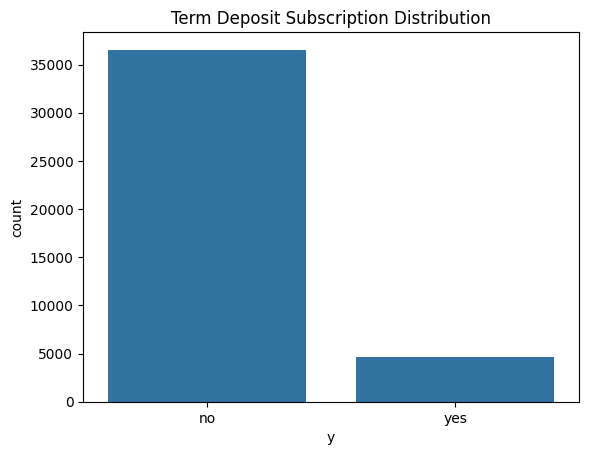

In [9]:
sns.countplot(data=df, x="y")
plt.title("Term Deposit Subscription Distribution")
plt.show()

##**Basic Data Understanding**

In [10]:
# Show categorical and numerical columns
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']

Numerical columns:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [11]:
# Unique values in categorical columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


job:
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

marital:
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

education:
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

default:
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

housing:
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

loan:
loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64

contact:
con

##**Prepare Features and Target**

In [12]:
# Copy dataset
df_model = df.copy()

# Convert target variable into binary
df_model["y"] = df_model["y"].map({"yes": 1, "no": 0})

# Remove duration to avoid data leakage
df_model = df_model.drop(columns=["duration"])

# Separate features and target
X = df_model.drop(columns=["y"])
y = df_model["y"]

# Identify categorical and numerical columns again
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numerical features: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


##**Train-Test Split**

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (32950, 19)
Testing set: (8238, 19)


##**Preprocessing Pipelines**

In [14]:
# Preprocessing for Logistic Regression
logistic_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Preprocessing for Random Forest
rf_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

##**Train Logistic Regression Model**

In [15]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", logistic_preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'campaign', 'pdays',
                                                   'previous', 'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

##**Train Random Forest Model**

In [16]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            max_depth=12,
            min_samples_split=10,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['age', 'campaign', 'pdays',
                                                   'previous', 'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=12,
                                        min_samples_split=10, n_estimators=200,
                                        n_jobs=-1, random_state=42))])

##**Model Evaluation Function**

In [18]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print(f"Model: {model_name}")
    print("=" * 50)
    print("Confusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("F1 Score:", round(f1, 4))
    print("ROC-AUC Score:", round(roc_auc, 4))

    # Confusion Matrix Plot
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, label=f"{model_name} AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend()
    plt.show()

##**Evaluate Logistic Regression**

Model: Logistic Regression
Confusion Matrix:
[[6279 1031]
 [ 328  600]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.86      0.90      7310
           1       0.37      0.65      0.47       928

    accuracy                           0.84      8238
   macro avg       0.66      0.75      0.69      8238
weighted avg       0.88      0.84      0.85      8238

F1 Score: 0.4689
ROC-AUC Score: 0.8009


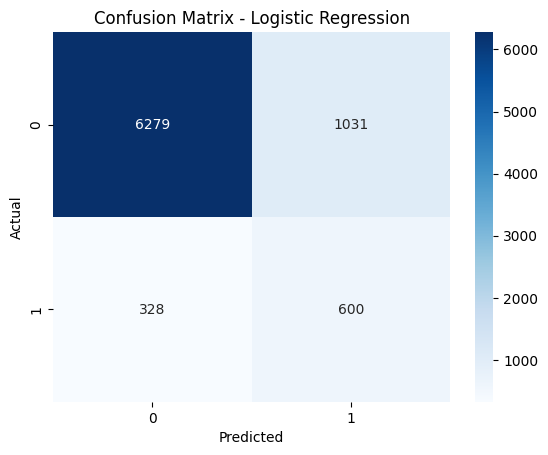

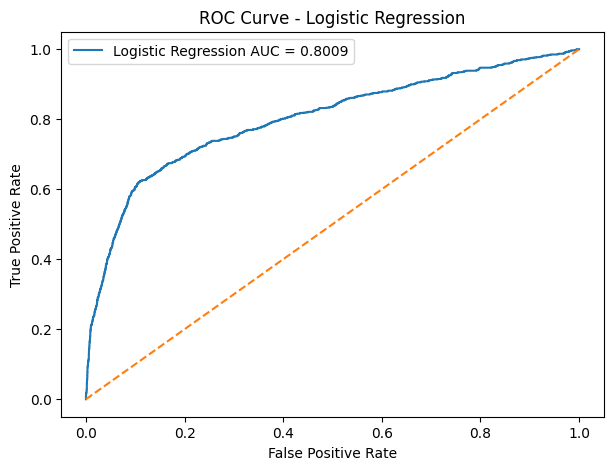

In [19]:

evaluate_model(logistic_model, X_test, y_test, "Logistic Regression")

##**Evaluate Random Forest**

Model: Random Forest
Confusion Matrix:
[[6577  733]
 [ 345  583]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.90      0.92      7310
           1       0.44      0.63      0.52       928

    accuracy                           0.87      8238
   macro avg       0.70      0.76      0.72      8238
weighted avg       0.89      0.87      0.88      8238

F1 Score: 0.5196
ROC-AUC Score: 0.8149


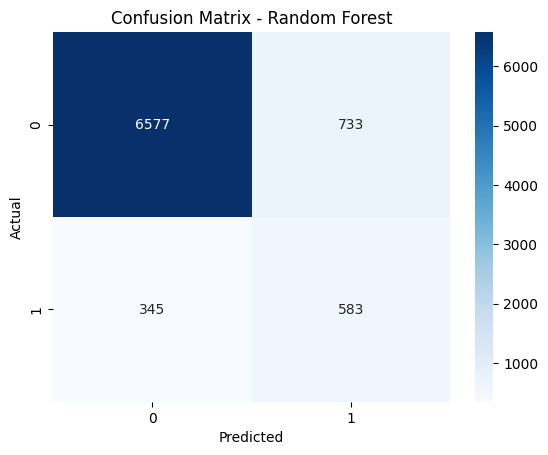

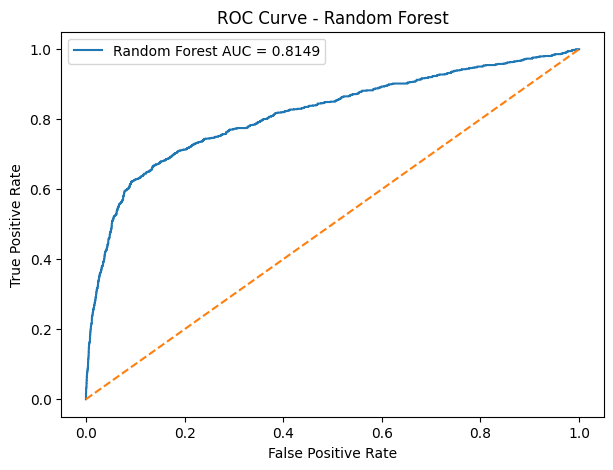

In [20]:

evaluate_model(rf_model, X_test, y_test, "Random Forest")

##**Compare Models**

In [22]:
models = {
    "Logistic Regression": logistic_model,
    "Random Forest": rf_model
}

comparison_results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    comparison_results.append({
        "Model": name,
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

comparison_df = pd.DataFrame(comparison_results)
comparison_df

,Model,F1 Score,ROC-AUC
0,Logistic Regression,0.468933,0.800942
1,Random Forest,0.519608,0.814887


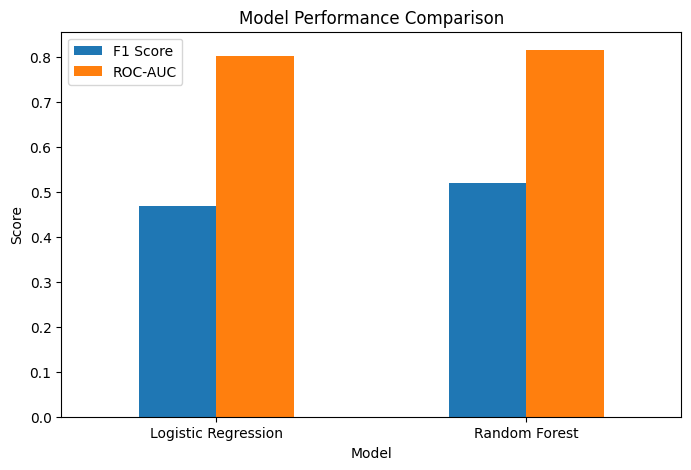

In [23]:
comparison_df.plot(
    x="Model",
    y=["F1 Score", "ROC-AUC"],
    kind="bar",
    figsize=(8, 5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

##**SHAP Explainability**
###We will explain predictions from the Random Forest model because it usually performs better and SHAP works well with tree-based models.

##**Prepare Data for SHAP**

In [24]:
# Extract trained preprocessor and classifier from Random Forest pipeline
trained_preprocessor = rf_model.named_steps["preprocessor"]
trained_rf_classifier = rf_model.named_steps["classifier"]

# Transform training and testing data
X_train_transformed = trained_preprocessor.transform(X_train)
X_test_transformed = trained_preprocessor.transform(X_test)

# Get feature names after one-hot encoding
feature_names = trained_preprocessor.get_feature_names_out()

# Convert transformed data into DataFrame
X_train_shap = pd.DataFrame(
    X_train_transformed.toarray() if hasattr(X_train_transformed, "toarray") else X_train_transformed,
    columns=feature_names
)

X_test_shap = pd.DataFrame(
    X_test_transformed.toarray() if hasattr(X_test_transformed, "toarray") else X_test_transformed,
    columns=feature_names
)

X_test_shap.head()

,num__age,num__campaign,num__pdays,num__previous,num__emp.var.rate,num__cons.price.idx,num__cons.conf.idx,num__euribor3m,num__nr.employed,cat__job_admin.,...,cat__month_oct,cat__month_sep,cat__day_of_week_fri,cat__day_of_week_mon,cat__day_of_week_thu,cat__day_of_week_tue,cat__day_of_week_wed,cat__poutcome_failure,cat__poutcome_nonexistent,cat__poutcome_success
0,32.0,5.0,999.0,0.0,1.4,93.918,-42.7,4.961,5228.1,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,37.0,1.0,999.0,0.0,-2.9,92.963,-40.8,1.262,5076.2,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,73.0,2.0,999.0,0.0,-1.7,94.215,-40.3,0.810,4991.6,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,44.0,2.0,999.0,0.0,1.4,94.465,-41.8,4.961,5228.1,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,28.0,2.0,999.0,0.0,-1.8,92.843,-50.0,1.531,5099.1,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


##**Create SHAP Explainer**

In [25]:
# Use TreeExplainer for Random Forest
explainer = shap.TreeExplainer(trained_rf_classifier)

# Select 5 predictions to explain
X_explain = X_test_shap.iloc[:5]

# Calculate SHAP values
shap_values = explainer.shap_values(X_explain)

##**Handle SHAP Output for Binary Classification**

In [26]:
# For binary classification, SHAP sometimes returns a list [class_0, class_1]
# We need SHAP values for class 1, meaning customer subscribes = yes

if isinstance(shap_values, list):
    shap_values_class_1 = shap_values[1]
    expected_value_class_1 = explainer.expected_value[1]
else:
    # For newer SHAP versions
    if len(shap_values.shape) == 3:
        shap_values_class_1 = shap_values[:, :, 1]
        expected_value_class_1 = explainer.expected_value[1]
    else:
        shap_values_class_1 = shap_values
        expected_value_class_1 = explainer.expected_value

##**Explain 5 Individual Predictions**


Prediction 1
Actual class: 0
Predicted class: 0
Predicted probability of subscription: 0.3951


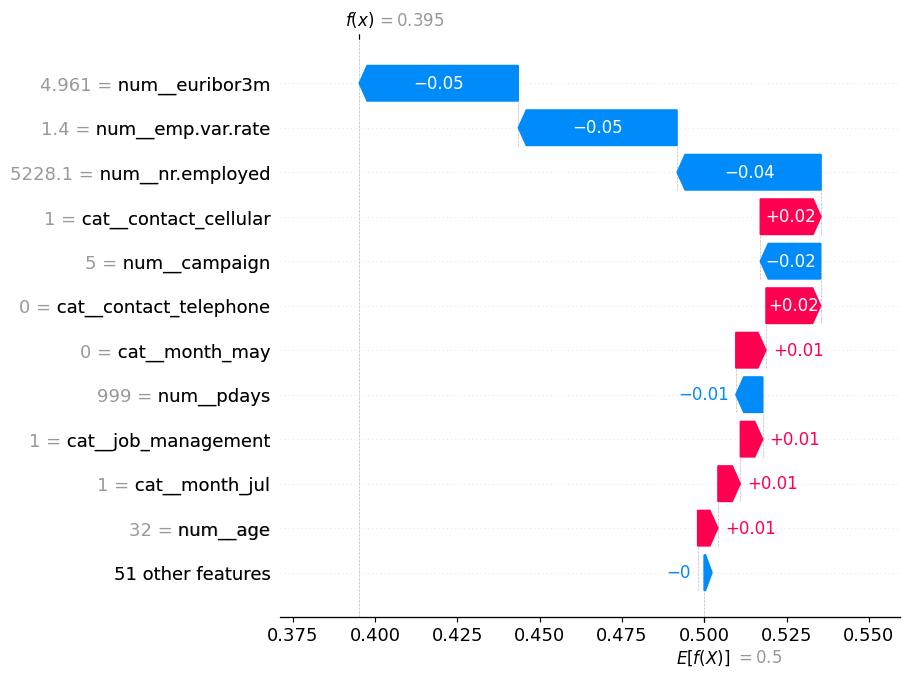


Prediction 2
Actual class: 0
Predicted class: 1
Predicted probability of subscription: 0.7584


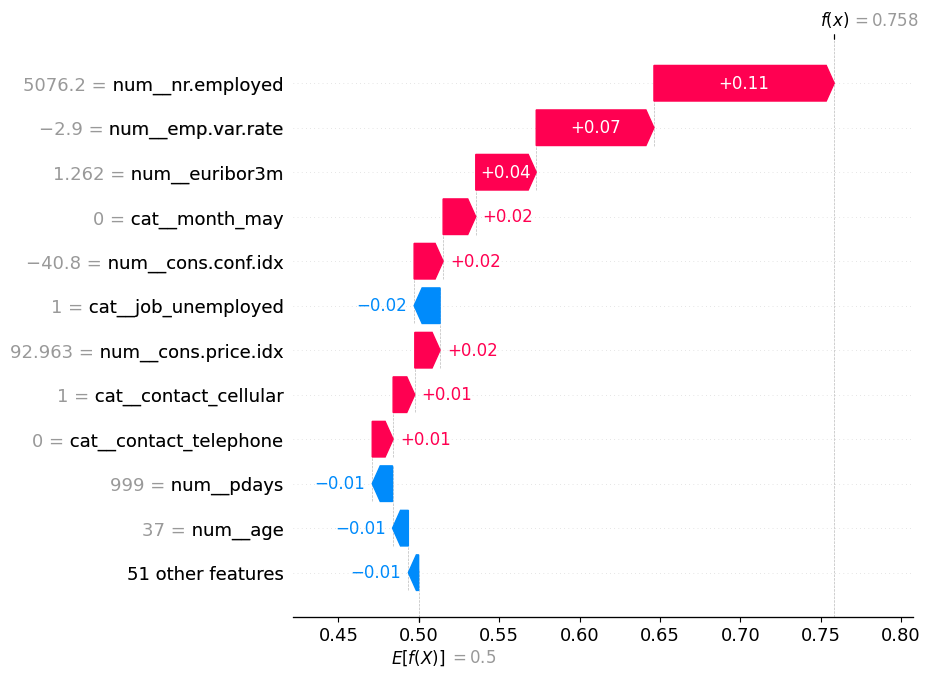


Prediction 3
Actual class: 0
Predicted class: 1
Predicted probability of subscription: 0.6842


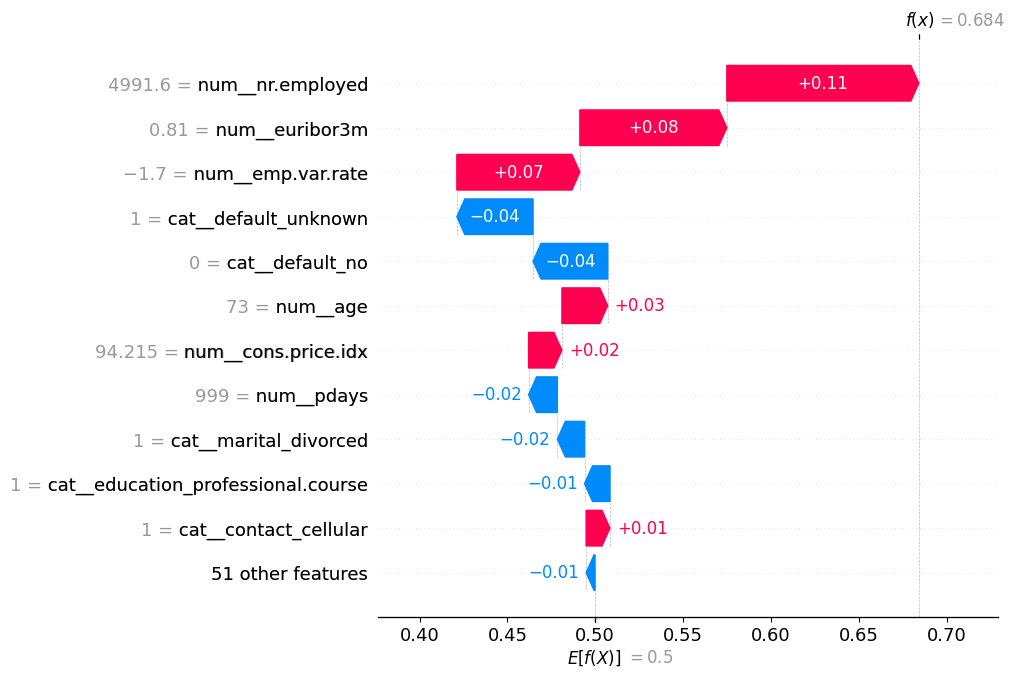


Prediction 4
Actual class: 0
Predicted class: 0
Predicted probability of subscription: 0.2244


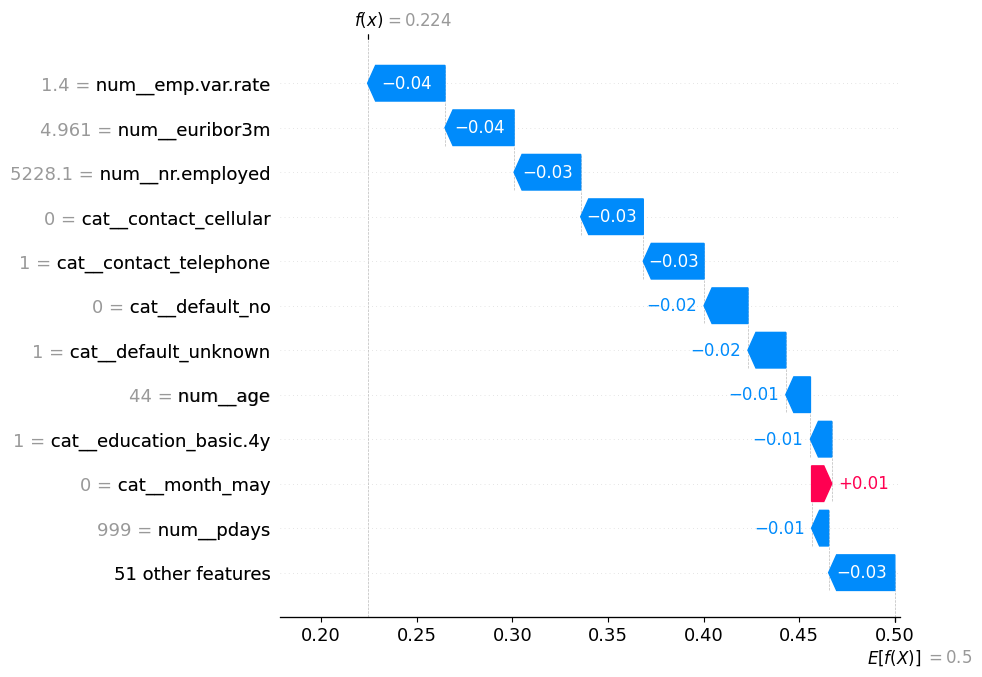


Prediction 5
Actual class: 0
Predicted class: 1
Predicted probability of subscription: 0.8397


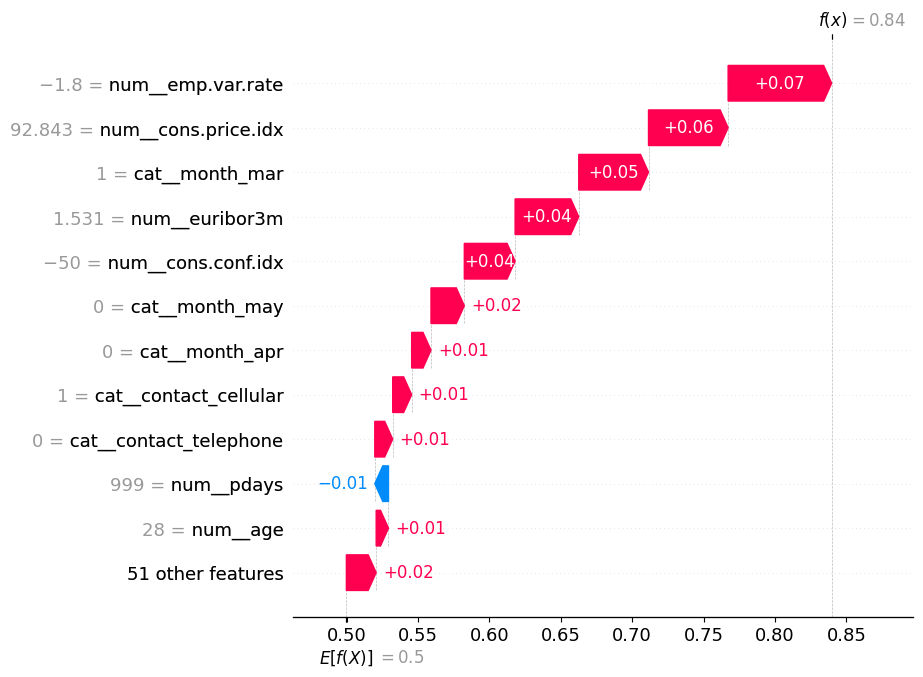

In [27]:
shap.initjs()

for i in range(5):
    predicted_class = rf_model.predict(X_test.iloc[[i]])[0]
    predicted_probability = rf_model.predict_proba(X_test.iloc[[i]])[:, 1][0]
    actual_class = y_test.iloc[i]

    print(f"\nPrediction {i+1}")
    print("=" * 50)
    print("Actual class:", actual_class)
    print("Predicted class:", predicted_class)
    print("Predicted probability of subscription:", round(predicted_probability, 4))

    explanation = shap.Explanation(
        values=shap_values_class_1[i],
        base_values=expected_value_class_1,
        data=X_explain.iloc[i],
        feature_names=feature_names
    )

    shap.plots.waterfall(explanation, max_display=12)

##**Global Feature Importance Using SHAP**

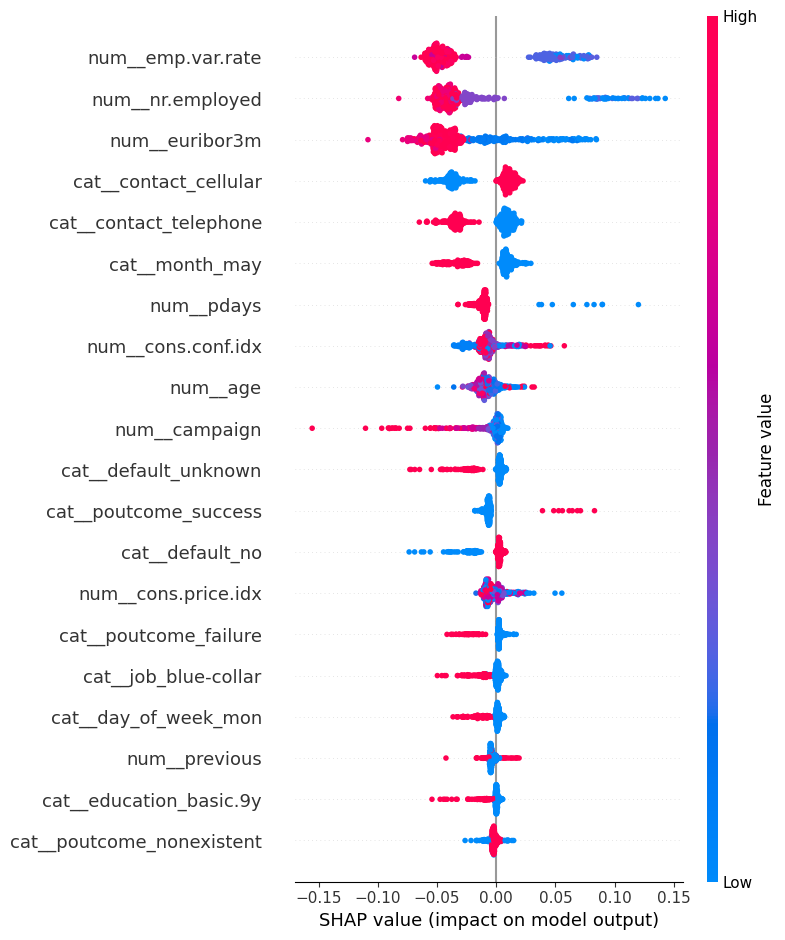

In [28]:
# Explain a larger sample for global interpretation
sample_size = 500

X_sample = X_test_shap.sample(sample_size, random_state=42)
shap_values_sample = explainer.shap_values(X_sample)

if isinstance(shap_values_sample, list):
    shap_values_sample_class_1 = shap_values_sample[1]
else:
    if len(shap_values_sample.shape) == 3:
        shap_values_sample_class_1 = shap_values_sample[:, :, 1]
    else:
        shap_values_sample_class_1 = shap_values_sample

shap.summary_plot(
    shap_values_sample_class_1,
    X_sample,
    feature_names=feature_names,
    max_display=20
)

##**Random Forest Feature Importance**

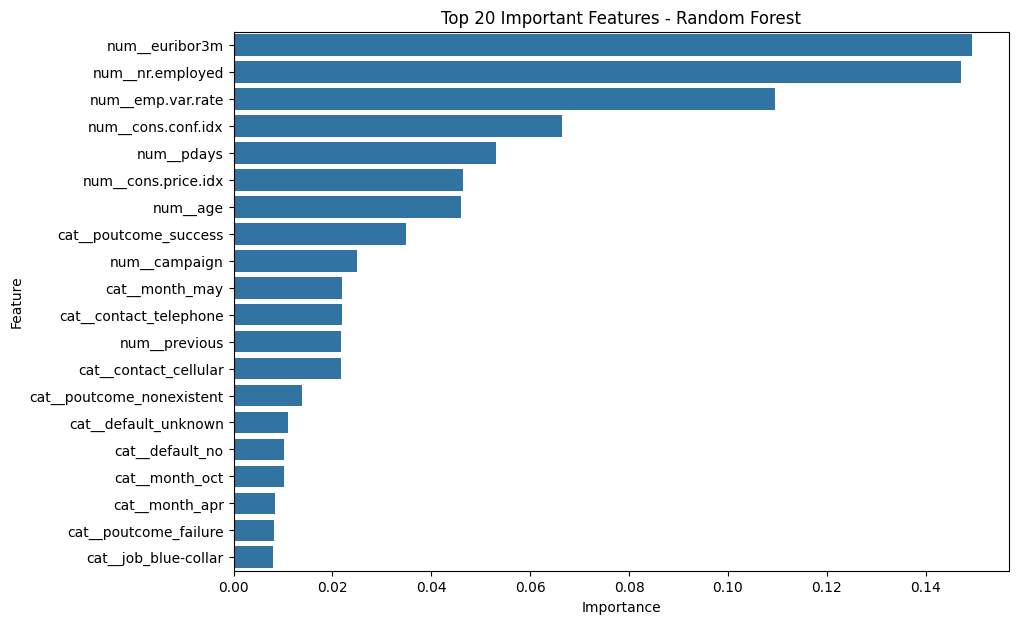

In [29]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": trained_rf_classifier.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)
plt.figure(figsize=(10, 7))
sns.barplot(
    data=feature_importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Important Features - Random Forest")
plt.show()

###**Conclusion:**

This project predicted whether a bank customer would subscribe to a term deposit after a marketing campaign.

The dataset was loaded from the UCI Machine Learning Repository and explored using descriptive statistics,
target distribution analysis, and categorical feature checks.

All categorical variables were properly encoded using One-Hot Encoding. Numerical variables were either
scaled for Logistic Regression or passed directly into the Random Forest model.

Two classification models were trained:
1. Logistic Regression
2. Random Forest Classifier

The models were evaluated using:
- Confusion Matrix
- F1 Score
- ROC-AUC Score
- ROC Curve

Because the dataset is imbalanced, F1 Score and ROC-AUC are more useful than simple accuracy.

SHAP was used to explain 5 individual predictions from the Random Forest model. The SHAP waterfall plots
showed which customer features pushed each prediction toward subscription or non-subscription.

Important features usually include:
- Previous campaign outcome
- Contact month
- Number of employees
- Euribor 3-month rate
- Consumer confidence index
- Contact type
- Job category
- Age

One important modeling decision was removing the duration column because it can cause data leakage.
Duration is only known after the marketing call, so using it would make the model unrealistically strong
for real-world pre-call prediction.